In [1]:
!pip install roboflow ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.2 MB/s eta 0:00:00


In [2]:
!pip install "sympy>=1.13.3,<1.14" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 49.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/fire_detection_runs"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Результаты будут сохраняться в: {SAVE_DIR}")

Mounted at /content/drive
Результаты будут сохраняться в: /content/drive/MyDrive/fire_detection_runs


In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="FgTggNleBDSyiYJD9oeL")
project = rf.workspace("georges-workspace-fnhr8").project("fire_detection-dtyvi")

print("Доступные версии:")
for v in project.versions():
    print(" -", v.version)

dataset = project.version(3).download("yolov11")
print(f"\nДатасет скачан: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Доступные версии:
 - 3
 - 2
 - 1
Exporting format yolov11 in progress : 8.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to Fire_detection-3 in yolov11:: 100%|██████████| 2053/2053 [00:00<00:00, 2575.11it/s]



Датасет скачан: /content/Fire_detection-3


In [5]:
import glob
from collections import Counter

DATASET_PATH = dataset.location

label_files = glob.glob(f"{DATASET_PATH}/**/*.txt", recursive=True)
label_files = [f for f in label_files if "data.yaml" not in f]

class_counts = Counter()
for label_file in label_files:
    with open(label_file, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            try:
                class_counts[int(parts[0])] += 1
            except (ValueError, IndexError):
                continue

print(f"Найдено файлов разметки: {len(label_files)}")
print("Распределение классов:")
for class_id, count in sorted(class_counts.items()):
    print(f"  Класс {class_id}: {count} инстансов")

Найдено файлов разметки: 1026
Распределение классов:
  Класс 0: 614 инстансов
  Класс 1: 2273 инстансов


In [7]:
import glob
import yaml
from collections import Counter

with open(f"{dataset.location}/data.yaml") as f:
    data_yaml = yaml.safe_load(f)

print("Классы в data.yaml:", data_yaml["names"])

label_files = glob.glob(f"{dataset.location}/**/*.txt", recursive=True)
label_files = [f for f in label_files if "data.yaml" not in f]

class_counts = Counter()
for label_file in label_files:
    with open(label_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    class_counts[int(line.split()[0])] += 1
                except (ValueError, IndexError):
                    continue

print("\nФинальное распределение классов:")
for class_id, count in sorted(class_counts.items()):
    class_name = data_yaml["names"][class_id]
    print(f"  Класс {class_id} ('{class_name}'): {count} инстансов")

Классы в data.yaml: ['1', 'fire']

Финальное распределение классов:
  Класс 0 ('1'): 614 инстансов
  Класс 1 ('fire'): 2273 инстансов


In [8]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=150,
    imgsz=640,
    batch=16,
    patience=30,
    device=0,
    project="fire_detection_runs",
    name="yolo11s_fire",

    # Аугментации (важно для небольшого датасета 800/200)
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0005,
    flipud=0.1,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.15,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # Регуляризация против переобучения
    dropout=0.1,
    weight_decay=0.0005,
    lr0=0.01,
    lrf=0.01,
    cos_lr=True,

    val=True,
    save_period=10,  # промежуточные чекпоинты каждые 10 эпох
)

print("Обучение завершено!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Fire_detection-3/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, 

In [9]:
import shutil, os

local_path = "/content/runs/detect/fire_detection_runs/yolo11s_fire"
drive_path = f"{SAVE_DIR}/yolo11s_fire"

if os.path.exists(drive_path):
    shutil.rmtree(drive_path)

shutil.copytree(local_path, drive_path)
print(f"✅ Сохранено: {drive_path}")

✅ Сохранено: /content/drive/MyDrive/fire_detection_runs/yolo11s_fire


In [10]:
best_model = YOLO(f"{drive_path}/weights/best.pt")
metrics = best_model.val()

print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall: {metrics.box.mr:.3f}")

Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1192.8±295.1 MB/s, size: 39.3 KB)
val: Scanning /content/Fire_detection-3/valid/labels.cache... 205 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 205/205 57.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.8it/s 4.7s
                   all        205        685      0.434      0.385      0.339      0.131
                     1        133        201      0.424      0.311      0.286      0.109
                  fire        196        484      0.445      0.459      0.392      0.153
Speed: 3.8ms preprocess, 9.6ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.339
mAP50-95: 0.131
Precision: 0.434
Recall: 0.385


Файлы в drive_path:
 - BoxF1_curve.png
 - BoxPR_curve.png
 - BoxP_curve.png
 - BoxR_curve.png
 - args.yaml
 - confusion_matrix.png
 - confusion_matrix_normalized.png
 - labels.jpg
 - results.csv
 - results.png
 - train_batch0.jpg
 - train_batch1.jpg
 - train_batch2.jpg
 - train_batch7140.jpg
 - train_batch7141.jpg
 - train_batch7142.jpg
 - val_batch0_labels.jpg
 - val_batch0_pred.jpg
 - val_batch1_labels.jpg
 - val_batch1_pred.jpg
 - val_batch2_labels.jpg
 - val_batch2_pred.jpg
 - weights

Найденные PR curve файлы: ['/content/drive/MyDrive/fire_detection_runs/yolo11s_fire/BoxPR_curve.png']

График обучения (loss, mAP по эпохам):


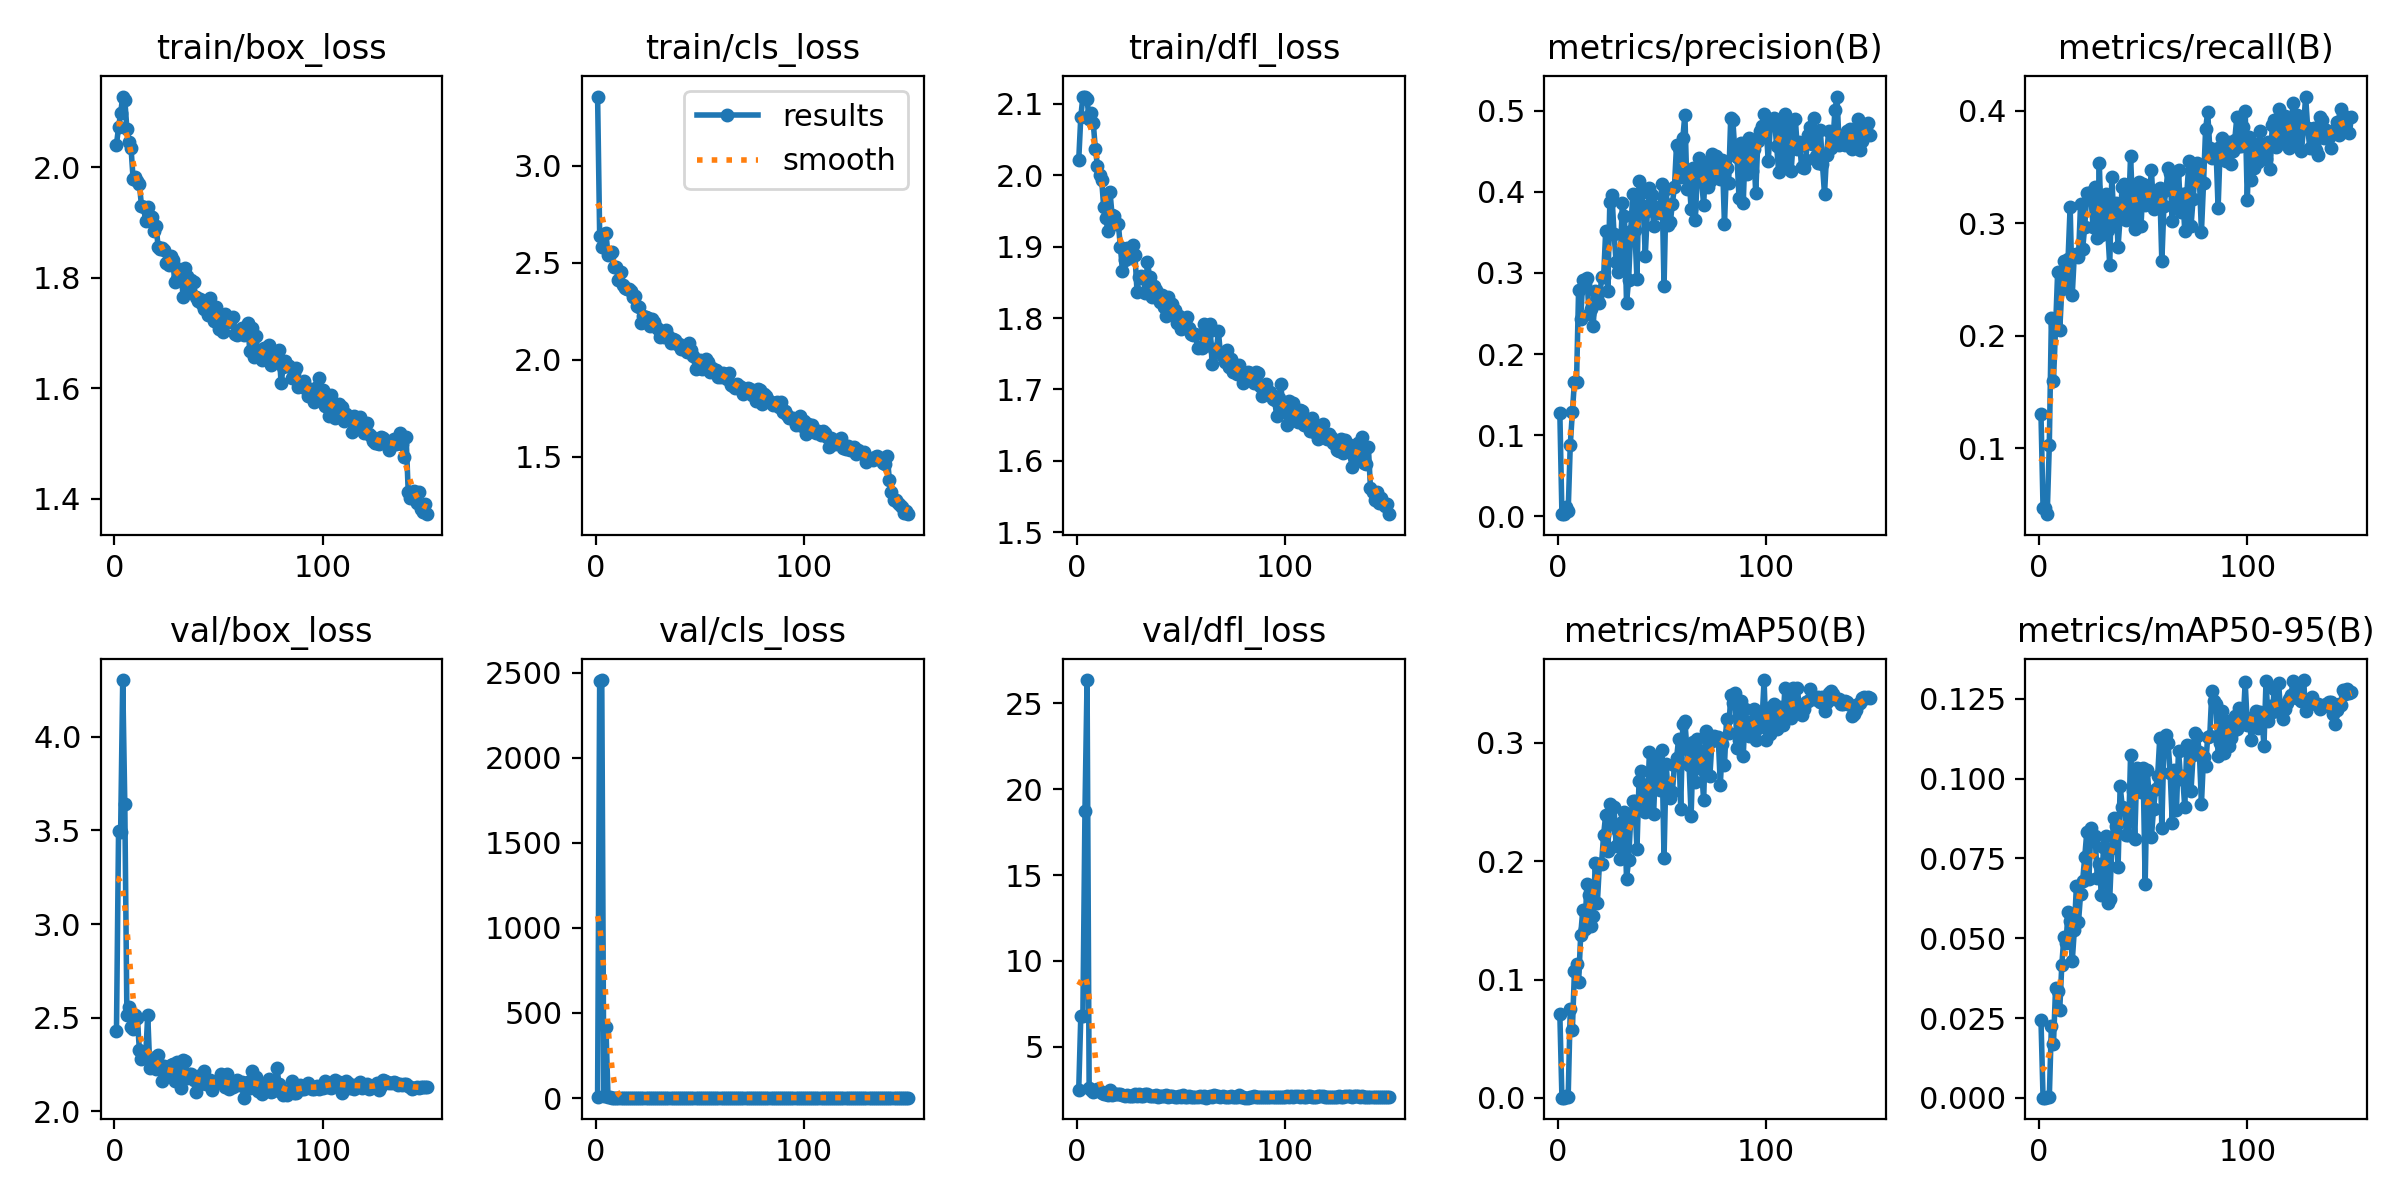


Матрица ошибок:


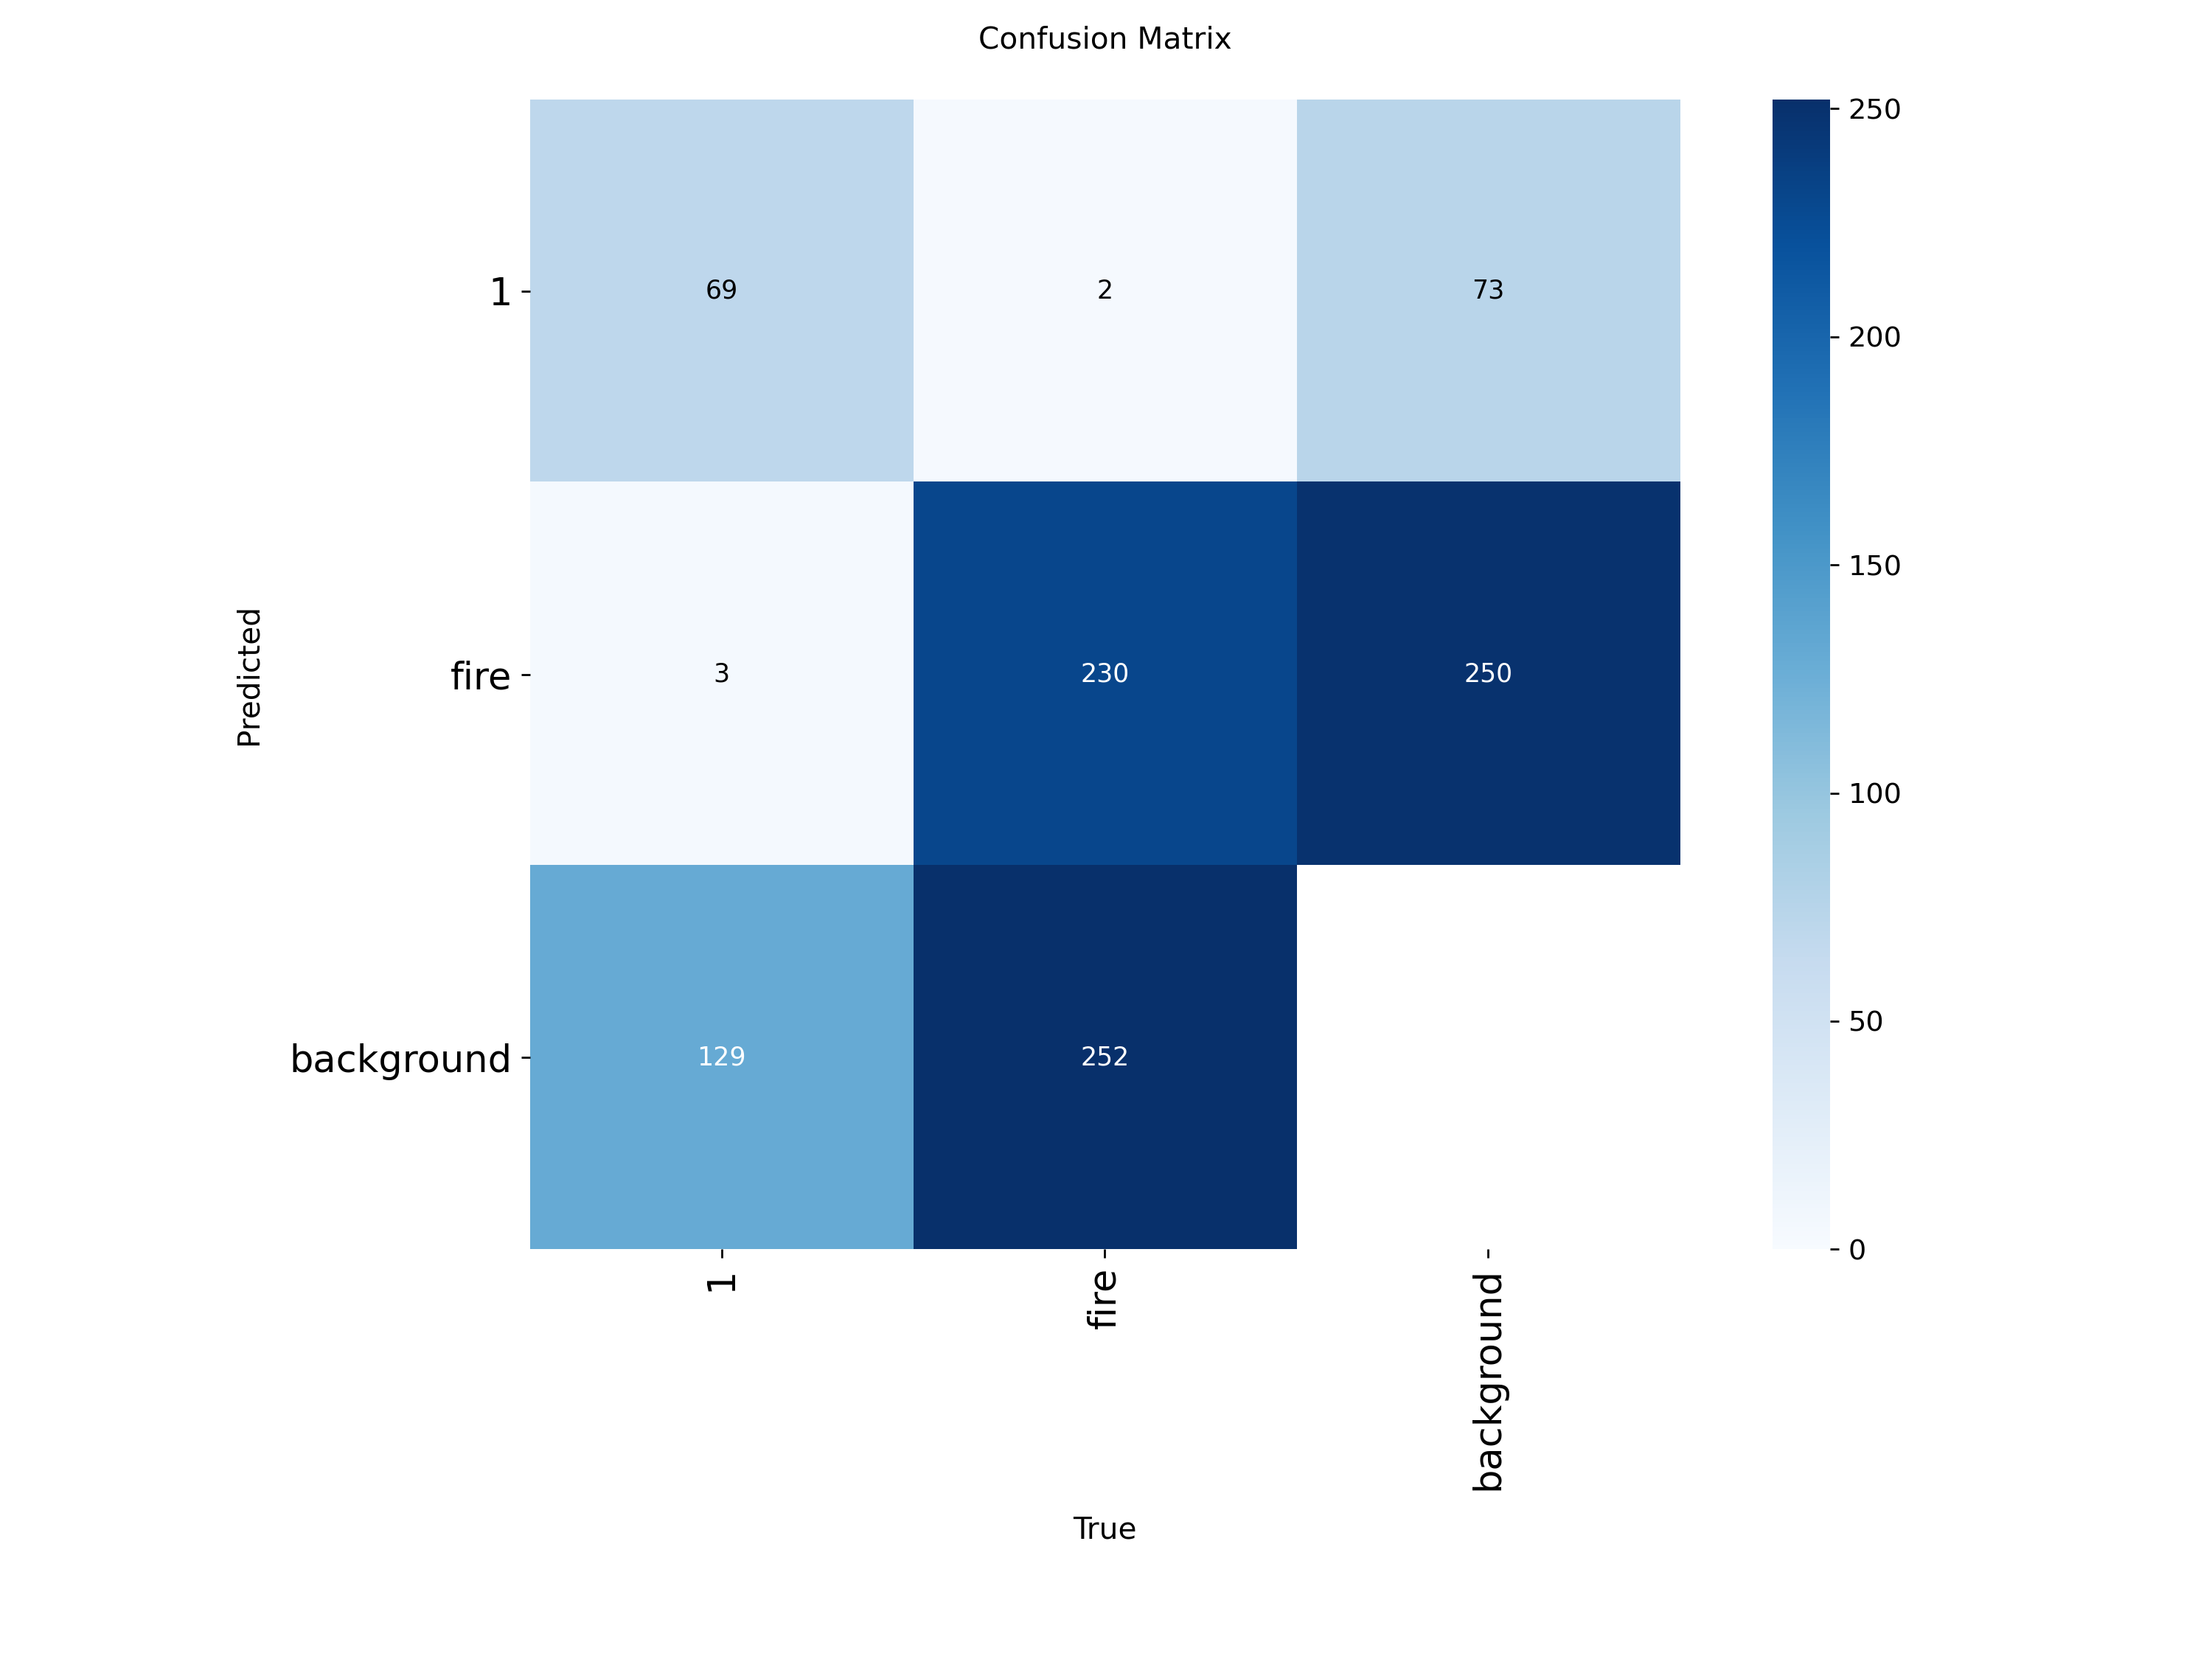


Precision-Recall кривая:


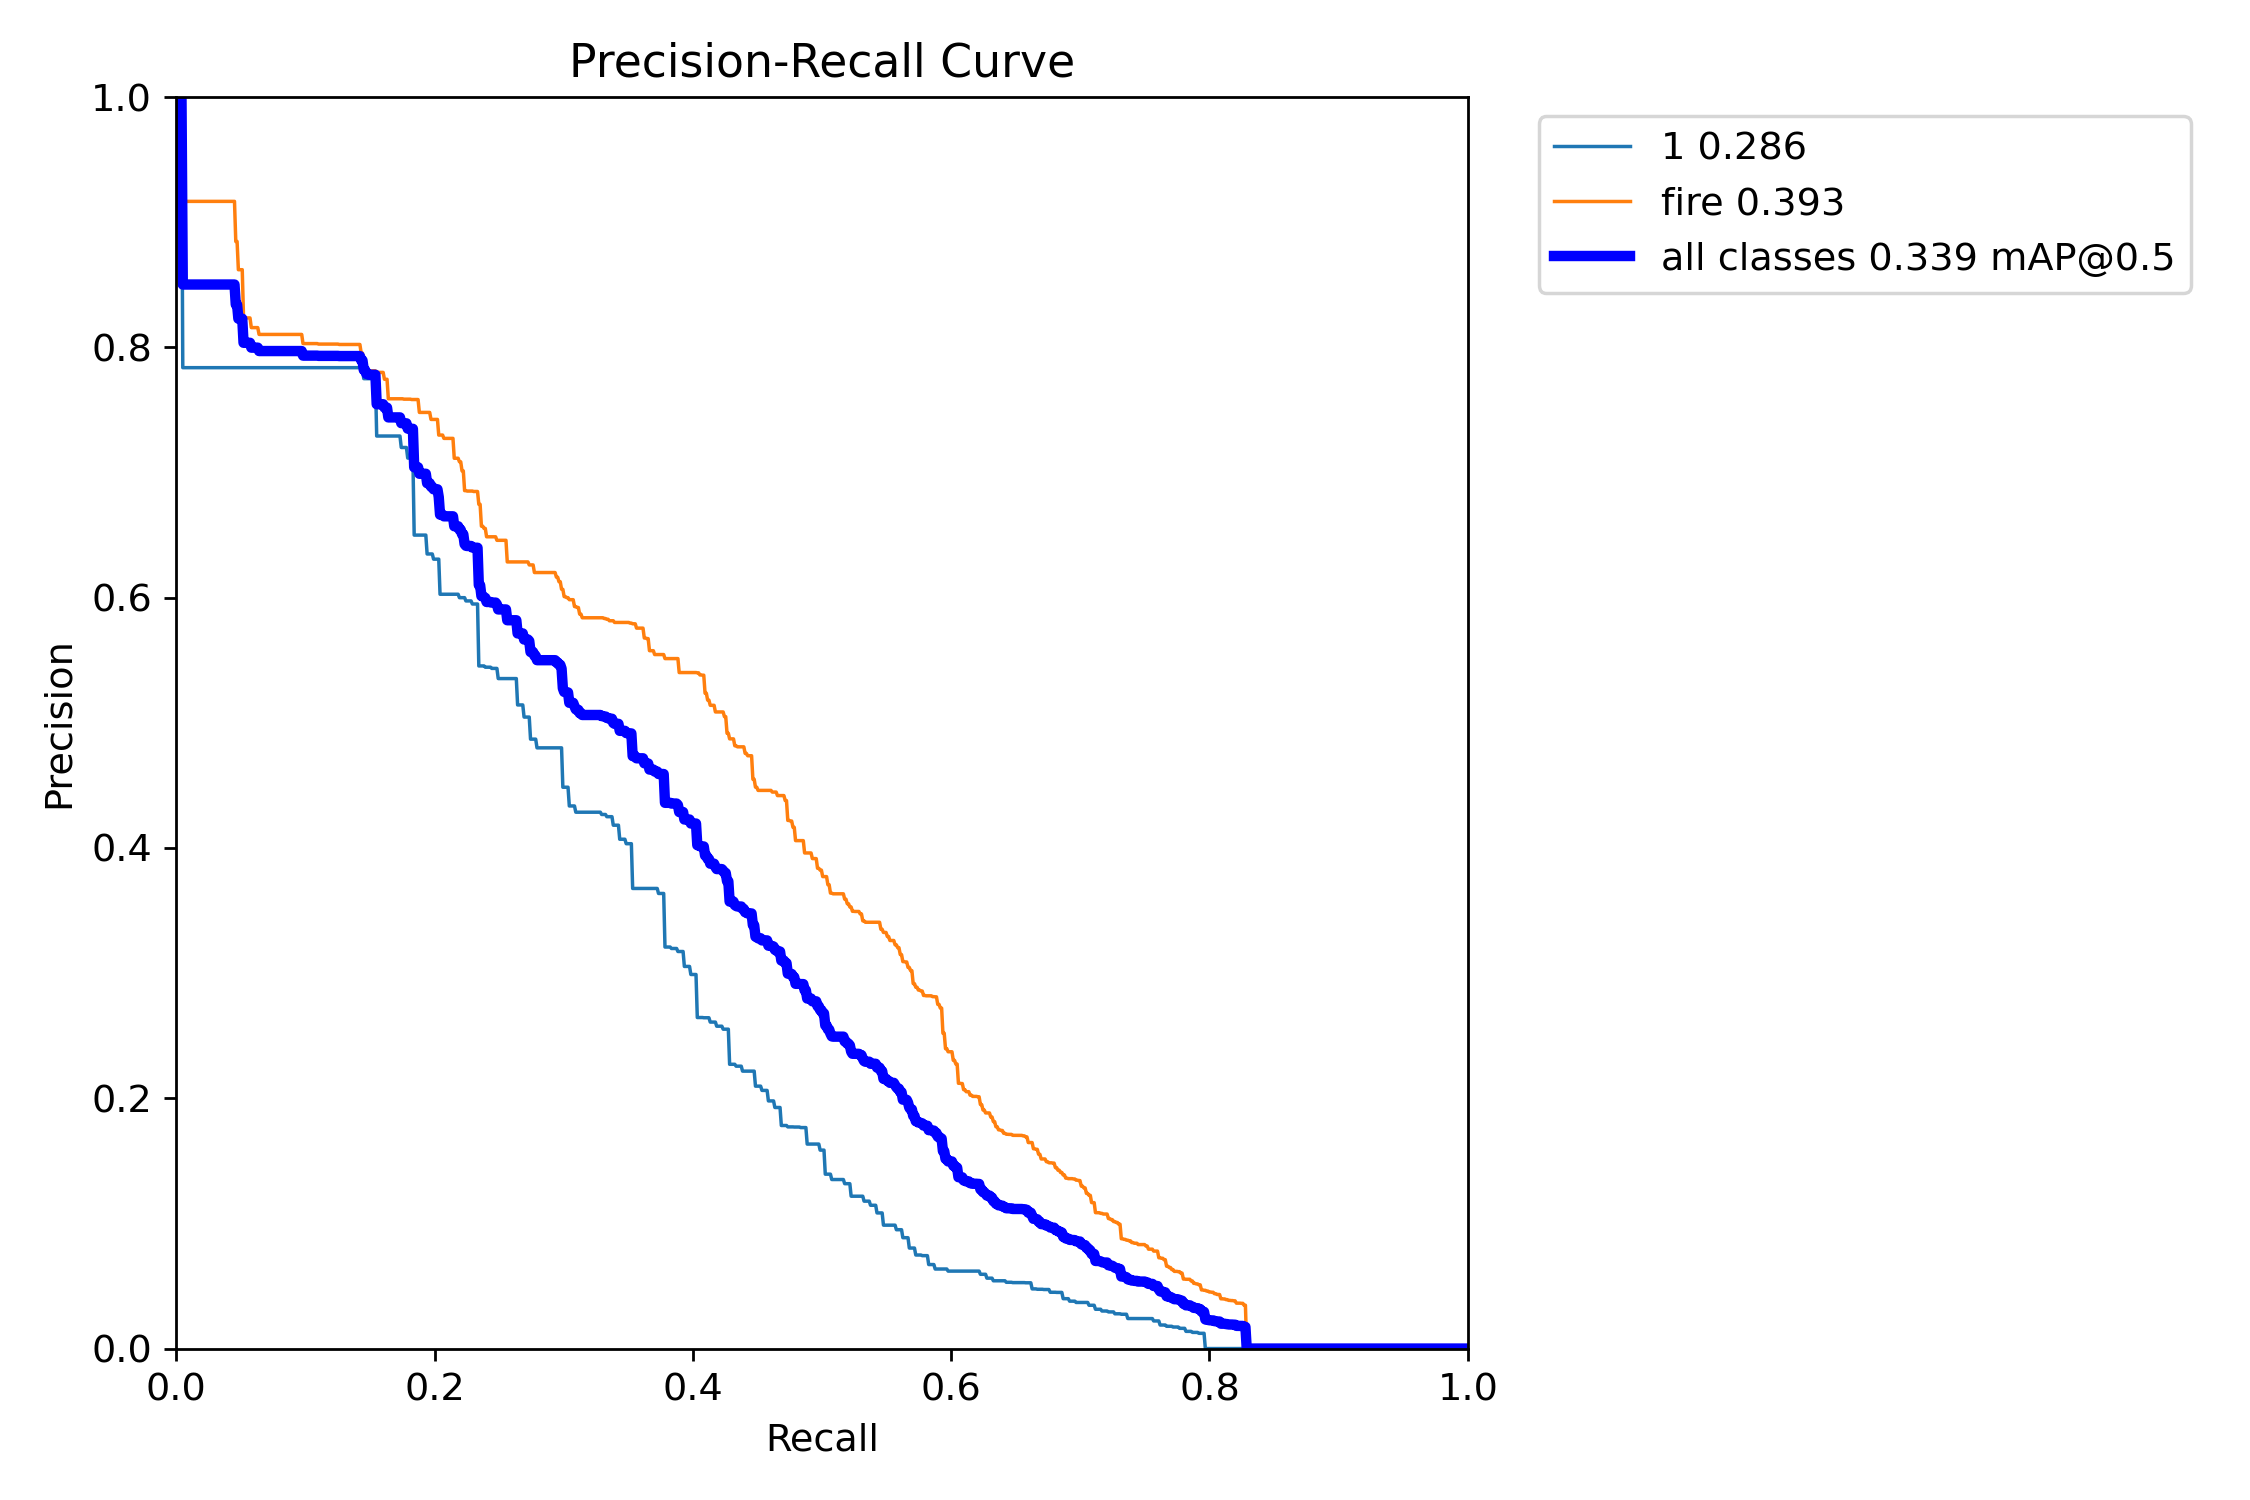


Папки в /content/runs/detect/:
 - fire_detection_runs
 - val


In [11]:
import os
import glob
from IPython.display import Image, display

print("Файлы в drive_path:")
for f in sorted(os.listdir(drive_path)):
    print(" -", f)

pr_files = glob.glob(f"{drive_path}/*PR_curve*") + glob.glob(f"{drive_path}/*pr_curve*")
print("\nНайденные PR curve файлы:", pr_files)

results_png = f"{drive_path}/results.png"
confusion_png = f"{drive_path}/confusion_matrix.png"

if os.path.exists(results_png):
    print("\nГрафик обучения (loss, mAP по эпохам):")
    display(Image(results_png))

if os.path.exists(confusion_png):
    print("\nМатрица ошибок:")
    display(Image(confusion_png))

if pr_files:
    print("\nPrecision-Recall кривая:")
    display(Image(pr_files[0]))
else:
    print("\n⚠️ PR curve файл не найден в drive_path")

print("\nПапки в /content/runs/detect/:")
if os.path.exists("/content/runs/detect/"):
    for f in sorted(os.listdir("/content/runs/detect/")):
        print(" -", f)

In [12]:
import pandas as pd

df = pd.read_csv(f"{drive_path}/results.csv")
print("Последние 10 эпох:")
print(df.tail(10))

Последние 10 эпох:
     epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
140    141  3024.25         1.41251         1.38037         1.56190   
141    142  3043.60         1.40092         1.31454         1.55647   
142    143  3062.74         1.40068         1.27774         1.54528   
143    144  3083.72         1.41454         1.27440         1.55636   
144    145  3102.87         1.39262         1.26067         1.54040   
145    146  3121.93         1.41301         1.24754         1.54790   
146    147  3142.45         1.38075         1.23760         1.54043   
147    148  3161.99         1.37578         1.20708         1.53700   
148    149  3180.99         1.39091         1.22038         1.53935   
149    150  3200.76         1.37214         1.20263         1.52522   

     metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
140               0.45286            0.38112           0.32260   
141               0.46752            0.38300           0.32439   
1